In [ ]:
pip install scikit-fuzzy

In [ ]:
import numpy as np
import skfuzzy
from skfuzzy import control
import matplotlib.pyplot as plt

# Entradas
sujeira = control.Antecedent(np.arange(0, 11, 0.5), 'sujeira')
quantidade = control.Antecedent(np.arange(0, 11, 0.5), 'quantidade')

# Saída
tempo = control.Consequent(np.arange(0, 61, 0.5), 'tempo')

# Funções de pertinência
sujeira['baixa'] = skfuzzy.trapmf(sujeira.universe, [0, 0, 2, 4])
sujeira['media'] = skfuzzy.trapmf(sujeira.universe, [2, 4, 6, 8])
sujeira['alta']  = skfuzzy.trapmf(sujeira.universe, [6, 8, 10, 10])

quantidade['pouca'] = skfuzzy.trapmf(quantidade.universe, [0, 0, 2, 4])
quantidade['media'] = skfuzzy.trapmf(quantidade.universe, [2, 4, 6, 8])
quantidade['muita'] = skfuzzy.trapmf(quantidade.universe, [6, 8, 10, 10])

tempo['curto'] = skfuzzy.trapmf(tempo.universe, [0, 0, 10, 25])
tempo['medio'] = skfuzzy.trapmf(tempo.universe, [20, 30, 40, 50])
tempo['longo'] = skfuzzy.trapmf(tempo.universe, [45, 55, 60, 60])

In [ ]:
# Regras fuzzy
regra1 = control.Rule(sujeira['baixa'] & quantidade['pouca'], tempo['curto'])
regra2 = control.Rule(sujeira['baixa'] & quantidade['media'], tempo['curto'])
regra3 = control.Rule(sujeira['baixa'] & quantidade['muita'], tempo['medio'])

regra4 = control.Rule(sujeira['media'] & quantidade['pouca'], tempo['medio'])
regra5 = control.Rule(sujeira['media'] & quantidade['media'], tempo['medio'])
regra6 = control.Rule(sujeira['media'] & quantidade['muita'], tempo['longo'])

regra7 = control.Rule(sujeira['alta'] & quantidade['pouca'], tempo['medio'])
regra8 = control.Rule(sujeira['alta'] & quantidade['media'], tempo['longo'])
regra9 = control.Rule(sujeira['alta'] & quantidade['muita'], tempo['longo'])

In [ ]:
# Sistema de controle
tempo_ctrl = control.ControlSystem([regra1, regra2, regra3, regra4, regra5, regra6, regra7, regra8, regra9])
lavagem = control.ControlSystemSimulation(tempo_ctrl)

Tempo recomendado de lavagem: 38.71 minutos


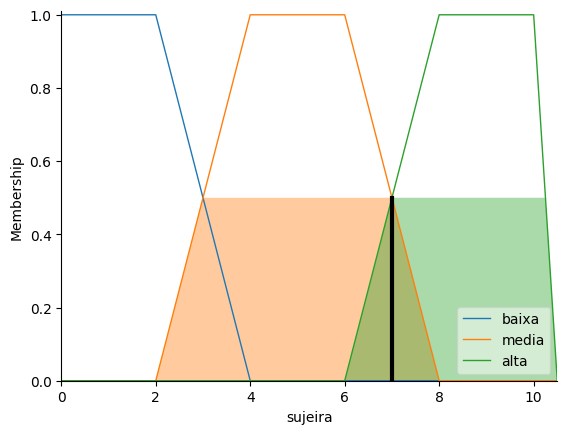

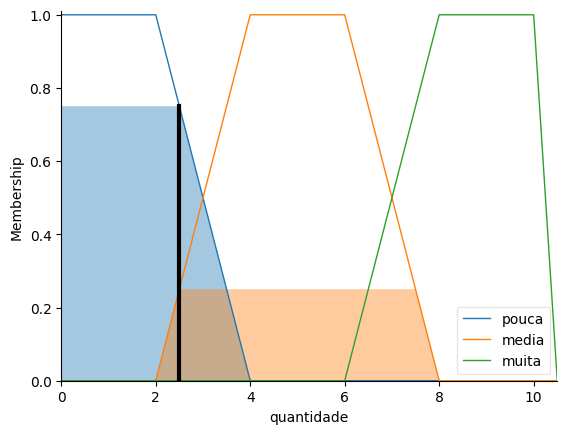

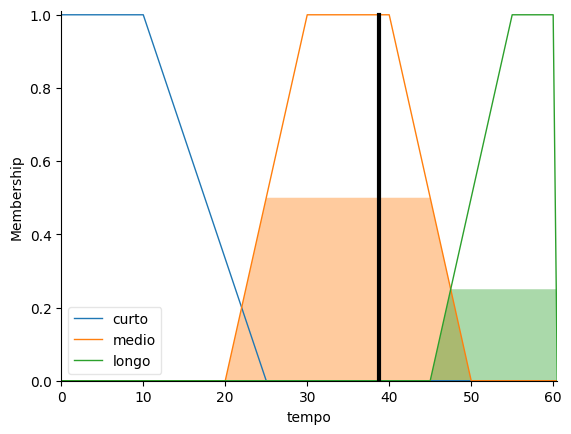

In [ ]:

lavagem.input['sujeira'] = 7
lavagem.input['quantidade'] = 2.5

lavagem.compute()

print(f"Tempo recomendado de lavagem: {lavagem.output['tempo']:.2f} minutos")

sujeira.view(sim=lavagem)
quantidade.view(sim=lavagem)
tempo.view(sim=lavagem)
plt.show()